# USDC-USDT Peg Deviation

# Data Download

### DEX Data

DEX data was collected from Dune using the query below. This generates an "out_of_band" variable that ends up being the main uniswap_volume in the data table.

```sql
WITH all_trades AS (
    SELECT * FROM dex.trades
    WHERE project_contract_address = 0x3416cf6c708da44db2624d63ea0aaef7113527c6
          AND block_date >= DATE '2025-07-01'
          AND block_date <= DATE '2025-09-30'
), flattened AS (
    SELECT block_time,
    CASE
        WHEN token_bought_symbol = 'USDC' THEN token_bought_amount
                                          ELSE -token_sold_amount 
    END AS amountUSDC,
    CASE
        WHEN token_bought_symbol = 'USDT' THEN token_bought_amount 
                                          ELSE -token_sold_amount
    END AS amountUSDT,
    CASE
        WHEN token_bought_symbol = 'USDC' THEN token_bought_amount / token_sold_amount 
                                          ELSE token_sold_amount / token_bought_amount
    END AS price
    FROM all_trades
), banded AS (
    SELECT *,
    (price > 1 + 0.001 OR price < 1 - 0.001) AS out_of_band,
    price * ABS(amountUSDC) AS volume
    FROM flattened
),
hourly AS (
  SELECT
    DATE_TRUNC('hour', block_time) AS time,
    MIN(price) AS uniswap_min_price,
    MAX(price) AS uniswap_max_price,
    SUM(volume) AS uniswap_volume,
    SUM(volume) FILTER (WHERE out_of_band) AS out_of_band_value
  FROM banded
  GROUP BY 1
)
SELECT
  *
FROM hourly
ORDER BY time DESC;
```

## CEX Data

Bybit Data was found using the historical data located at [https://public.bybit.com/trading/USDCUSDT/](https://public.bybit.com/trading/USDCUSDT/).
The code to fetch this is located in `utils/BybitDL.py`.

## Merging for final Output

Taking the raw Bybit data and Uniswap data from Dune, `utils/BybitUniswapProcess.py` cleans the file's dates, interpolates missing dates, and merges the two files forming the final file located at `data/merged.csv`.

# Review

Below is visualization code to compare trading volumes.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("data/merged.csv", header=0)

It's clear from the data that bybit has extremely tight trades and has almost no volume out of bounds in the trades downloaded. There are only 3 hours where this occured where the prices dropped to 0.998 or 0.997.

In [9]:
df.query("bybit_volume > 0")[["time", "bybit_volume", "bybit_min_price", "bybit_max_price"]]

,time,bybit_volume,bybit_min_price,bybit_max_price
277,2025-07-12 13:00:00+00:00,175223.17808,0.9984,1.0004
278,2025-07-12 14:00:00+00:00,412564.39872,0.9976,1.0008
279,2025-07-12 15:00:00+00:00,128039.64192,0.9976,0.9995


The code below generates a stacked bar plot to compare Uniswap and Bybit Volumes. From the data for Uniswap trades, there are far more trades that occur out of bounds. Bybit's hour stack is highlighted in yellow, while Uniswap is Blue and for simplicity the visualization aggregates across days instead of hours.

The highest peak happened on August 15 which correlates to the Bitcoin crash to $110K, where we had a large deleveraging event. It' possible to see the Bybit peg break, but it's volume is extremely tiny versus onchain flows out of bounds.

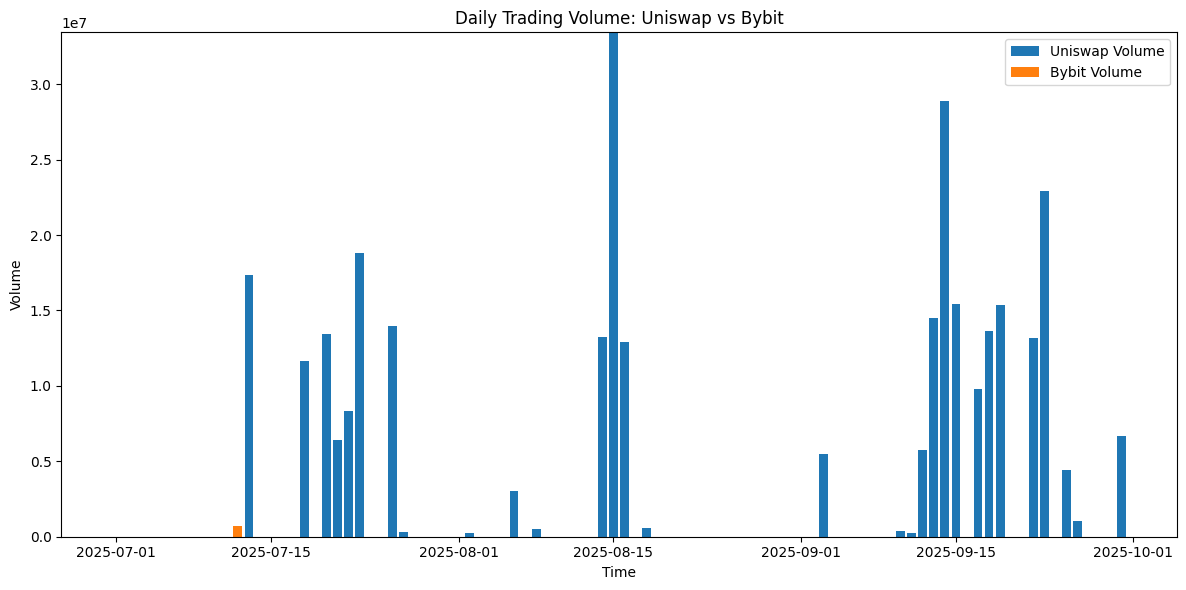

In [11]:
df["time"] = pd.to_datetime(df["time"])

daily = (
    df.groupby(pd.Grouper(key="time", freq="D"))[["uniswap_volume", "bybit_volume"]]
    .sum()
    .reset_index()
)

# Set timestamp as x-axis
x = daily["time"]
uniswap = daily["uniswap_volume"]
bybit = daily["bybit_volume"]

# Create stacked bar chart
plt.figure(figsize=(12, 6))
plt.bar(x, uniswap, label="Uniswap Volume", color="#1f77b4")
plt.bar(x, bybit, bottom=uniswap, label="Bybit Volume", color="#ff7f0e")

plt.title("Daily Trading Volume: Uniswap vs Bybit")
plt.xlabel("Time")
plt.ylabel("Volume")
plt.legend()
plt.tight_layout()
plt.show()